In [17]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import pandas as pd

In [ ]:
a = np.array([
    [2,1],
    [4,3]
])

np.linalg.

In [2]:
a = np.array([
    [2,0],
    [0,3]
])

values, vectors = np.linalg.eig(a)

print(values)
print(vectors)

[2.+0.j 3.+0.j]
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]


In [ ]:
iris = load_iris()

x = iris.data

cov = np.cov(x.T)

print(cov)

[[ 0.68569351 -0.042434    1.27431544  0.51627069]
 [-0.042434    0.18997942 -0.32965638 -0.12163937]
 [ 1.27431544 -0.32965638  3.11627785  1.2956094 ]
 [ 0.51627069 -0.12163937  1.2956094   0.58100626]]


In [ ]:


x_scaled = StandardScaler().fit_transform(x)

cov = np.cov(x_scaled)

values, vectors = np.linalg.eig(cov)

print("Eigvalues")
print(values)
print("\nEigvectors")
print(vectors)

Eigvalues
[ 9.64293985e+01+0.00000000e+00j  8.75247320e+00+0.00000000e+00j
  1.30751552e+00+0.00000000e+00j -7.90499645e-15+0.00000000e+00j
 -6.28114061e-15+0.00000000e+00j -1.28225289e-15+5.47979768e-15j
 -1.28225289e-15-5.47979768e-15j -2.68490575e-15+4.61554339e-15j
 -2.68490575e-15-4.61554339e-15j  2.59213383e-15+4.11330200e-15j
  2.59213383e-15-4.11330200e-15j  4.71135898e-15+1.38193322e-16j
  4.71135898e-15-1.38193322e-16j  1.43871989e-15+4.34605607e-15j
  1.43871989e-15-4.34605607e-15j -4.36203213e-15+0.00000000e+00j
 -2.50440736e-15+3.51437779e-15j -2.50440736e-15-3.51437779e-15j
  2.25836018e-16+4.26949902e-15j  2.25836018e-16-4.26949902e-15j
  3.32078799e-15+2.42043683e-15j  3.32078799e-15-2.42043683e-15j
  1.28573073e-15+3.54280471e-15j  1.28573073e-15-3.54280471e-15j
  3.75890150e-15+5.20767618e-16j  3.75890150e-15-5.20767618e-16j
 -3.11547230e-15+6.37782379e-16j -3.11547230e-15-6.37782379e-16j
 -2.41461586e-15+1.98368244e-15j -2.41461586e-15-1.98368244e-15j
  1.35118089e-1

In [9]:
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)

print("Original shape", x.shape)
print("Reduced shape", x_pca.shape)

Original shape (150, 4)
Reduced shape (150, 2)


Text(0.5, 1.0, 'PCA on Iris DataSet')

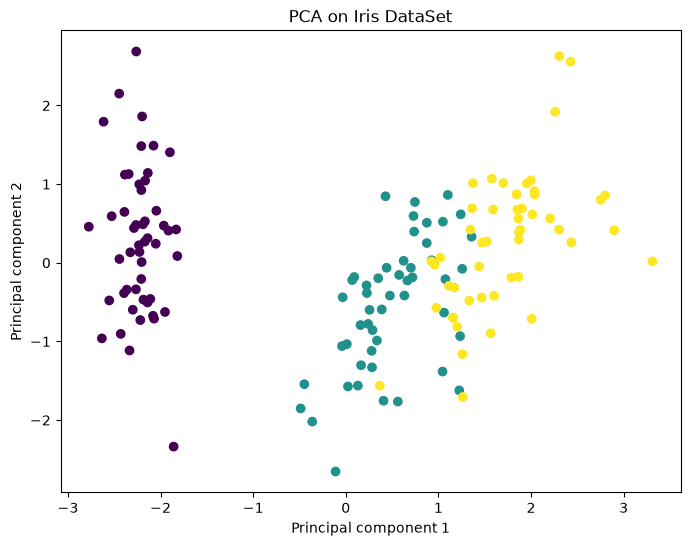

In [10]:
plt.figure(figsize=(8,6))

plt.scatter(
    x_pca[:,0],
    x_pca[:,1],
    c=iris.target
)

plt.xlabel("Principal component 1")
plt.ylabel("Principal component 2")
plt.title("PCA on Iris DataSet")

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

x_train, x_test, y_train, y_test = train_test_split(
    x_scaled,
    iris.target,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier(random_state=42)
model.fit(x_train, y_train)

pred = model.predict(x_test)

print("Accuracy (Original):", accuracy_score(y_test, pred))

#PCA data
x_train_pca, x_test_pca, y_train_pca, y_test_pca = train_test_split(
    x_pca,
    iris.target,
    test_size=0.2,
    random_state=42
)

model.fit(x_train_pca, y_train)

pred = model.predict(x_test_pca)

print("Accuracy (PCA)", accuracy_score(y_test, pred))

Accuracy (Original): 1.0
Accuracy (PCA) 0.9


In [18]:
df = pd.DataFrame({
    "Eigenvalue": values
})

df = df.sort_values("Eigenvalue", ascending=False)

print(df)

                    Eigenvalue
0   9.642940e+01+0.000000e+00j
1   8.752473e+00+0.000000e+00j
2   1.307516e+00+0.000000e+00j
11  4.711359e-15+1.381933e-16j
12  4.711359e-15-1.381933e-16j
..                         ...
26 -3.115472e-15+6.377824e-16j
27 -3.115472e-15-6.377824e-16j
15 -4.362032e-15+0.000000e+00j
4  -6.281141e-15+0.000000e+00j
3  -7.904996e-15+0.000000e+00j

[150 rows x 1 columns]
